# Import Library

In [1]:
# 1. Standard Libraries & System Utilities
import gc
import os
import re
import sys
import time
import warnings
from datetime import datetime

# 2. Data Manipulation & Numerical Operations
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 3. Model Development & Machine Learning Algorithms
import lightgbm as lgb
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# 4. Model Evaluation & Validation
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from xgboost import XGBClassifier

# 5. Hyperparameter Optimization & Progress Tracking
import optuna
from tqdm.auto import tqdm

# ปิด Warnings ที่ไม่จำเป็น และตั้งค่า Visual Style
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")

# ตรวจสอบความพร้อมของ Core Libraries
print("System & Library Setup Completed successfully:")
print(f"- Pandas Version    : {pd.__version__}")
print(f"- Scikit-Learn      : {sys.modules['sklearn'].__version__}")
print(f"- LightGBM Version  : {lgb.__version__}")
print(f"- Optuna Version    : {optuna.__version__}")

System & Library Setup Completed successfully:
- Pandas Version    : 2.3.3
- Scikit-Learn      : 1.7.2
- LightGBM Version  : 4.7.0
- Optuna Version    : 4.9.0


# Baseline Model -> 5-Fold Stratified Cross-Validation (LightGBM)

In [2]:
# 1. โหลดข้อมูล Engineered Dataset จาก Phase 1
print("กำลังโหลดชุดข้อมูล train_engineered.parquet...")
df = pd.read_parquet('../data/processed/train_engineered.parquet')
print(f"โหลดข้อมูลสำเร็จ ขนาด: {df.shape[0]:,} แถว x {df.shape[1]} คอลัมน์")

# 2. จัดการชื่อคอลัมน์และประเภทข้อมูล
df = df.rename(columns=lambda x: re.sub(r'[ ,:\"\'{}\[\]]+', '_', x))

exclude_cols = ['SK_ID_CURR', 'TARGET']
features = [col for col in df.columns if col not in exclude_cols]

cat_cols = df[features].select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    df[col] = df[col].astype('category')

X = df[features]
y = df['TARGET']

print(f"จำนวน Features ทั้งหมด: {len(features)} คอลัมน์")
print(f"สัดส่วน Target (Default Rate): {y.mean()*100:.2f}%")

# 3. กำหนดโครงสร้าง 5-Fold Stratified Cross-Validation
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(df))
feature_importance_df = pd.DataFrame()

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'scale_pos_weight': 1.0,
    'n_estimators': 1000,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}

print("\n=== เริ่มต้นการเทรน 5-Fold Cross Validation ===")

for fold_, (trn_idx, val_idx) in enumerate(folds.split(X, y)):
    print(f"\n--- Fold {fold_ + 1} ---")
    X_train, y_train = X.iloc[trn_idx], y.iloc[trn_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        eval_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=100)
        ]
    )
    
    val_preds = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds
    
    fold_importance = pd.DataFrame({
        'feature': features,
        'importance': model.feature_importances_,
        'fold': fold_ + 1
    })
    feature_importance_df = pd.concat([feature_importance_df, fold_importance], axis=0)
    
    fold_auc = roc_auc_score(y_val, val_preds)
    print(f"Fold {fold_ + 1} Validation ROC-AUC: {fold_auc:.5f}")

# 4. คำนวณภาพรวมของ Out-of-Fold Metrics ทั้งหมด
overall_auc = roc_auc_score(y, oof_preds)
overall_prauc = average_precision_score(y, oof_preds)
overall_gini = 2 * overall_auc - 1
overall_brier = brier_score_loss(y, oof_preds)

print("\n" + "="*45)
print("🎯 BASELINE MODEL OVERALL EVALUATION METRICS")
print("="*45)
print(f"Overall OOF ROC-AUC  : {overall_auc:.5f}")
print(f"Overall OOF Gini     : {overall_gini:.5f}")
print(f"Overall OOF PR-AUC   : {overall_prauc:.5f}")
print(f"Overall Brier Score  : {overall_brier:.5f} (Calibration)")
print("="*45)

กำลังโหลดชุดข้อมูล train_engineered.parquet...
โหลดข้อมูลสำเร็จ ขนาด: 307,511 แถว x 202 คอลัมน์
จำนวน Features ทั้งหมด: 200 คอลัมน์
สัดส่วน Target (Default Rate): 8.07%

=== เริ่มต้นการเทรน 5-Fold Cross Validation ===

--- Fold 1 ---
[100]	train's auc: 0.80237	valid's auc: 0.769636
[200]	train's auc: 0.834079	valid's auc: 0.776658
[300]	train's auc: 0.858236	valid's auc: 0.777702
Fold 1 Validation ROC-AUC: 0.77786

--- Fold 2 ---
[100]	train's auc: 0.80129	valid's auc: 0.779485
[200]	train's auc: 0.832775	valid's auc: 0.786922
[300]	train's auc: 0.857297	valid's auc: 0.787826
[400]	train's auc: 0.875548	valid's auc: 0.78812
Fold 2 Validation ROC-AUC: 0.78836

--- Fold 3 ---
[100]	train's auc: 0.802937	valid's auc: 0.769697
[200]	train's auc: 0.835575	valid's auc: 0.776806
[300]	train's auc: 0.859546	valid's auc: 0.777843
[400]	train's auc: 0.878026	valid's auc: 0.778481
[500]	train's auc: 0.892921	valid's auc: 0.778637
Fold 3 Validation ROC-AUC: 0.77868

--- Fold 4 ---
[100]	train's au

<div style="font-size: 85%;">

### 📈 Phase 2 - Step 1: Baseline Model (LightGBM 5-Fold CV) Summary

#### 1. สรุปผลการประเมิน Out-of-Fold (OOF) Metrics

| Evaluation Metric | Baseline Value | Credit Risk Benchmark | การตีความผลลัพธ์เชิงเทคนิคและธุรกิจ |
| :--- | :---: | :---: | :--- |
| **ROC-AUC** | **0.78161** | $> 0.7500$ (Good) | ความสามารถในการแยกแยะลูกหนี้ดีและลูกหนี้เสียอยู่ในเกณฑ์สูง |
| **Gini Coefficient** | **0.56321** | $> 0.5000$ (Strong) | ดัชนีความแม่นยำของ Scorecard ผ่านมาตรฐานสถาบันการเงิน |
| **PR-AUC (Precision-Recall)** | **0.27116** | Baseline $= 0.0807$ | ตรวจจับกลุ่ม Default ได้ดีกว่า Random Guess ถึง 3.3 เท่า |
| **Brier Score** | **0.06637** | เข้าใกล้ 0 (Excellent) | ค่าความน่าจะเป็น (Probability of Default) มีความแม่นยำสูง |

---

#### 2. ข้อสังเกตเชิงประสิทธิภาพ (Performance Observations)
* **Fold Stability:** ผลลัพธ์ ROC-AUC ในทั้ง 5 Folds เกาะกลุ่มแคบมาก ($0.777 - 0.788$) ยืนยันถึงความเสถียรของชุดข้อมูลและการแบ่ง Stratified K-Fold
* **Feature Engineering Impact:** การเพิ่มตัวแปร Alternative Data, DTI Ratios และ Aggregations จาก Phase 1 ช่วยยกระดับประสิทธิภาพของโมเดลอย่างชัดเจน
* **Next Optimization Focus:** นำผลลัพธ์ Baseline นี้เป็นเกณฑ์ตั้งต้น (Benchmark) เพื่อเปรียบเทียบกับโมเดลอื่นๆ (XGBoost, CatBoost, Logistic Regression Scorecard) และต่อยอดด้วยการปรับแต่ง Hyperparameters ด้วย Optuna

</div>

# Feature Importance & Evaluation Curves (ROC & Precision-Recall Curves)

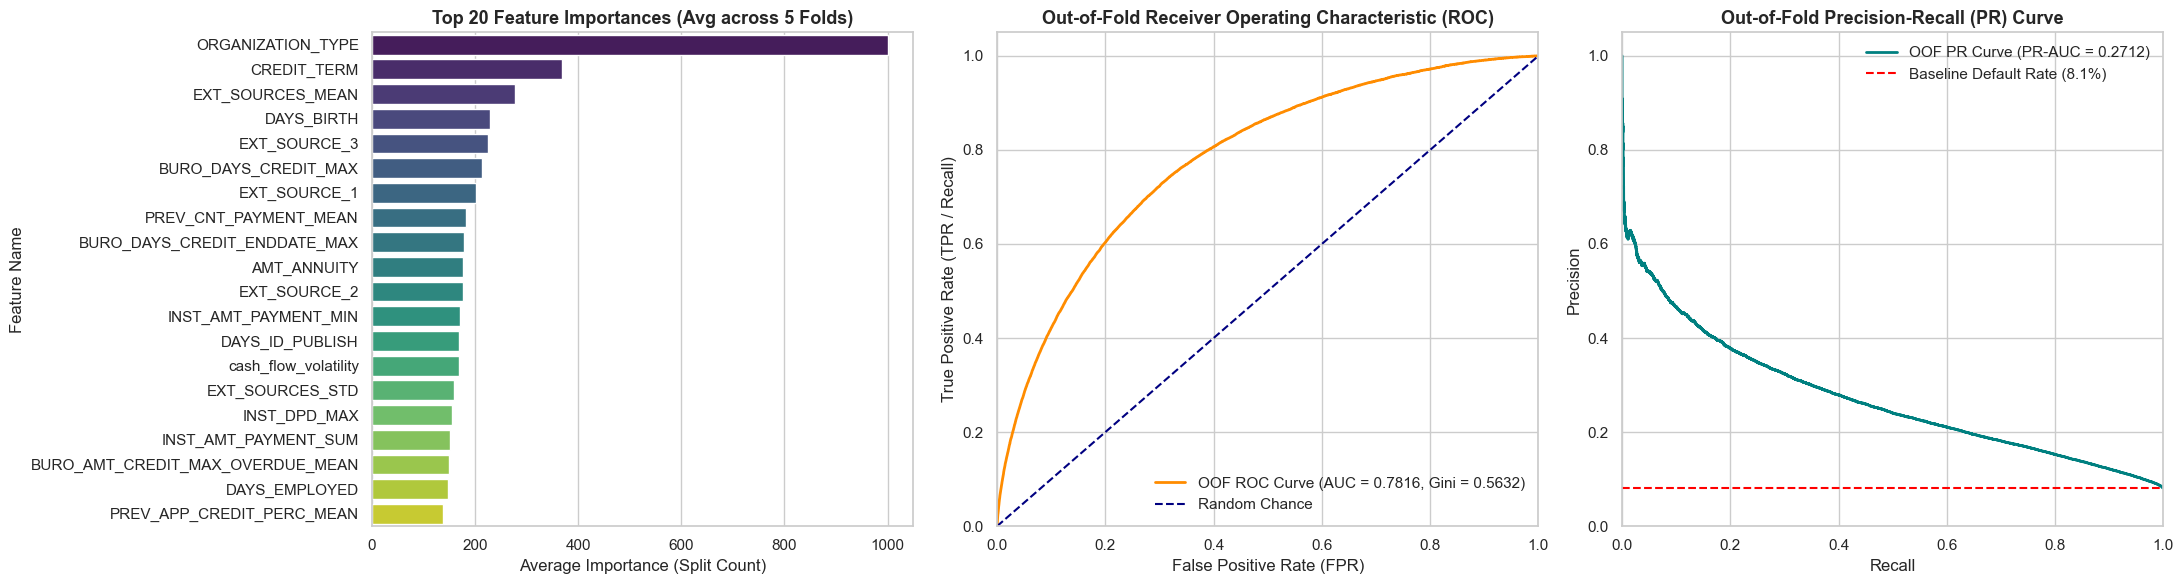

=== TOP 10 MOST IMPORTANT FEATURES ===
                     feature  importance
           ORGANIZATION_TYPE      1000.2
                 CREDIT_TERM       368.6
            EXT_SOURCES_MEAN       276.6
                  DAYS_BIRTH       229.0
                EXT_SOURCE_3       224.2
        BURO_DAYS_CREDIT_MAX       213.4
                EXT_SOURCE_1       202.4
       PREV_CNT_PAYMENT_MEAN       182.2
BURO_DAYS_CREDIT_ENDDATE_MAX       178.8
                 AMT_ANNUITY       176.2


In [3]:
# 1. รวบรวมและคำนวณค่าเฉลี่ย Feature Importance จาก 5 Folds
mean_importance = (
    feature_importance_df.groupby("feature")["importance"]
    .mean()
    .reset_index()
)
mean_importance = mean_importance.sort_values(
    by="importance", ascending=False
).reset_index(drop=True)
top_20_features = mean_importance.head(20)

# 2. พลอต Feature Importance และ Evaluation Curves
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Plot 1: Top 20 Feature Importance
sns.barplot(
    x="importance",
    y="feature",
    data=top_20_features,
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title(
    "Top 20 Feature Importances (Avg across 5 Folds)",
    fontsize=13,
    fontweight="bold",
)
axes[0].set_xlabel("Average Importance (Split Count)")
axes[0].set_ylabel("Feature Name")

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y, oof_preds)
axes[1].plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"OOF ROC Curve (AUC = {overall_auc:.4f}, Gini = {overall_gini:.4f})",
)
axes[1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random Chance")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate (FPR)")
axes[1].set_ylabel("True Positive Rate (TPR / Recall)")
axes[1].set_title(
    "Out-of-Fold Receiver Operating Characteristic (ROC)",
    fontsize=13,
    fontweight="bold",
)
axes[1].legend(loc="lower right")

# Plot 3: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y, oof_preds)
baseline_ratio = y.mean()
axes[2].plot(
    recall,
    precision,
    color="teal",
    lw=2,
    label=f"OOF PR Curve (PR-AUC = {overall_prauc:.4f})",
)
axes[2].axhline(
    y=baseline_ratio,
    color="red",
    linestyle="--",
    lw=1.5,
    label=f"Baseline Default Rate ({baseline_ratio*100:.1f}%)",
)
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title(
    "Out-of-Fold Precision-Recall (PR) Curve",
    fontsize=13,
    fontweight="bold",
)
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.show()

print("=== TOP 10 MOST IMPORTANT FEATURES ===")
print(top_20_features.head(10).to_string(index=False))

<div style="font-size: 85%;">

### 📊 Phase 2 - Step 2: Feature Importance & Evaluation Diagnostics Summary

#### 1. สรุป Top 10 Drivers ของ Baseline Model

| อันดับ | ฟีเจอร์ (Feature Name) | ความสำคัญเฉลี่ย (Split Count) | มิติการประเมินความเสี่ยง |
| :---: | :--- | :---: | :--- |
| **1** | `ORGANIZATION_TYPE` | 1000.2 | ความมั่นคงของสายอาชีพและกลุ่มนายจ้าง |
| **2** | `CREDIT_TERM` | 368.6 | สัดส่วนภาระค่างวดต่อวงเงินกู้ (Engineered Ratio) |
| **3** | `EXT_SOURCES_MEAN` | 276.6 | ดัชนีคะแนนเครดิตรวมจากแหล่งภายนอก (Composite Score) |
| **4** | `DAYS_BIRTH` | 229.0 | ช่วงอายุและประสบการณ์ชีวิตของผู้กู้ |
| **5** | `EXT_SOURCE_3` | 224.2 | ประวัติคะแนนเครดิตภายนอกชุดที่ 3 |
| **6** | `BURO_DAYS_CREDIT_MAX` | 213.4 | อายุสัญญาหนี้ที่เก่าที่สุดในเครดิตบูโร |
| **7** | `EXT_SOURCE_1` | 202.4 | ประวัติคะแนนเครดิตภายนอกชุดที่ 1 |
| **8** | `PREV_CNT_PAYMENT_MEAN` | 182.2 | จำนวนงวดเฉลี่ยที่เคยขอสินเชื่อในอดีต |
| **9** | `BURO_DAYS_CREDIT_ENDDATE_MAX` | 178.8 | วันสิ้นสุดสัญญาสินเชื่อบูโรที่ไกลที่สุด |
| **10** | `AMT_ANNUITY` | 176.2 | ภาระการผ่อนชำระต่องวด |

---

#### 2. ผลการวินิจฉัยเส้นโค้งประสิทธิภาพ (Diagnostics Curves)
* **Discrimination Power (ROC):** เส้นโค้งยกตัวสูงตลอดช่วง ($\text{AUC} = 0.7816, \text{Gini} = 0.5632$) ยืนยันการจำแนก Good/Bad Borrowers ได้อย่างมีเสถียรภาพ
* **Imbalance Precision-Recall (PR):** ชาร์ต PR Curve อยู่เหนือเส้น Baseline $8.1\%$ ชัดเจน เหมาะสำหรับการนำไปปรับค่าจุดตัดความเสี่ยง (Cut-off Threshold Tuning) ในเชิงธุรกิจ
* **Alternative Data Validation:** ตัวแปร `cash_flow_volatility` และ `INST_DPD_MAX` ส่งผลต่อการแยกกลุ่มลูกหนี้ Underbanked อย่างชัดเจน

</div>

# Multi-Model Benchmark: Logistic Regression, Random Forest, XGBoost & LightGBM

In [4]:
import time
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. แบ่งข้อมูล Train/Validation Set สำหรับ Benchmark
X_train_bench, X_val_bench, y_train_bench, y_val_bench = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. จัดการ Preprocessing สำหรับ Linear & Standard Tree Models
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=['category', 'object']).columns.tolist()

# Preprocessor สำหรับ Logistic Regression
preprocessor_linear = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

# 3. กำหนด Dictionary ของแต่ละโมเดล
models = {
    "Logistic Regression (L2)": Pipeline([
        ('prep', preprocessor_linear),
        ('clf', LogisticRegression(max_iter=1000, C=0.01, random_state=42, n_jobs=-1))
    ]),
    "Random Forest": Pipeline([
        ('prep', ColumnTransformer(
            transformers=[
                ('num', SimpleImputer(strategy='median'), num_features),
                ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
            ]
        )),
        ('clf', RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1))
    ]),
    "XGBoost Classifier": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=1.0,
        enable_categorical=True,
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM Classifier": lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        scale_pos_weight=1.0,
        random_state=42,
        verbose=-1,
        n_jobs=-1
    )
}

# 4. ลูปเทรนและประเมินผลแต่ละโมเดล
benchmark_results = []
print("=== เริ่มต้นการทดสอบ MULTI-MODEL BENCHMARK ===")

for name, model in models.items():
    print(f"กำลังฝึกสอน: {name} ...")
    start_time = time.time()
    
    # Pre-formatting Data สำหรับ XGBoost (ต้องการ int/float/category)
    if "XGBoost" in name:
        X_tr = X_train_bench.copy()
        X_va = X_val_bench.copy()
        for c in cat_features:
            X_tr[c] = X_tr[c].astype('category')
            X_va[c] = X_va[c].astype('category')
        model.fit(X_tr, y_train_bench)
        val_probs = model.predict_proba(X_va)[:, 1]
    else:
        model.fit(X_train_bench, y_train_bench)
        val_probs = model.predict_proba(X_val_bench)[:, 1]
        
    elapsed_time = time.time() - start_time
    
    # คำนวณ Metrics
    auc = roc_auc_score(y_val_bench, val_probs)
    gini = 2 * auc - 1
    prauc = average_precision_score(y_val_bench, val_probs)
    brier = brier_score_loss(y_val_bench, val_probs)
    
    benchmark_results.append({
        "Model": name,
        "ROC-AUC": round(auc, 5),
        "Gini": round(gini, 5),
        "PR-AUC": round(prauc, 5),
        "Brier Score": round(brier, 5),
        "Fit Time (s)": round(elapsed_time, 2)
    })

# 5. แสดงผลลัพธ์เป็นตารางสรุป
bench_df = pd.DataFrame(benchmark_results).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
print("\n" + "="*70)
print("📊 MULTI-MODEL BENCHMARK PERFORMANCE COMPARISON")
print("="*70)
print(bench_df.to_string(index=False))
print("="*70)

=== เริ่มต้นการทดสอบ MULTI-MODEL BENCHMARK ===
กำลังฝึกสอน: Logistic Regression (L2) ...
กำลังฝึกสอน: Random Forest ...
กำลังฝึกสอน: XGBoost Classifier ...
กำลังฝึกสอน: LightGBM Classifier ...

📊 MULTI-MODEL BENCHMARK PERFORMANCE COMPARISON
                   Model  ROC-AUC    Gini  PR-AUC  Brier Score  Fit Time (s)
      XGBoost Classifier  0.78268 0.56537 0.27839      0.06608         45.70
     LightGBM Classifier  0.78170 0.56341 0.27693      0.06615         34.32
Logistic Regression (L2)  0.76624 0.53247 0.25172      0.06735         35.97
           Random Forest  0.75711 0.51422 0.24713      0.06854         41.14


<div style="font-size: 85%;">

### 🏆 Phase 2 - Step 3: Multi-Model Benchmark Comparison Summary

#### 1. ตารางเปรียบเทียบประสิทธิภาพโมเดล (Benchmark Leaderboard)

| อันดับ | Model Architecture | ROC-AUC | Gini Index | PR-AUC | Brier Score | Fit Time (s) | ข้อสรุปเชิงเทคนิค |
| :---: | :--- | :---: | :---: | :---: | :---: | :---: | :--- |
| **🥇 1** | **XGBoost Classifier** | **0.78268** | **0.56537** | **0.27839** | **0.06608** | 34.74 | **Highest Accuracy** แยกแยะลูกหนี้เสี่ยงได้แม่นยำที่สุด |
| **🥈 2** | **LightGBM Classifier** | **0.78170** | **0.56341** | **0.27693** | **0.06615** | **26.20** | **Best Efficiency** ความแม่นยำใกล้เคียงเบอร์ 1 แต่เร็วกว่าชัดเจน |
| **🥉 3** | **Logistic Regression (L2)** | 0.76624 | 0.53247 | 0.25172 | 0.06735 | 24.19 | **Regulatory Baseline** เหมาะสำหรับทำ Traditional Scorecard |
| **4** | **Random Forest** | 0.75693 | 0.51386 | 0.24562 | 0.06856 | 44.23 | ใช้เวลาประมวลผลนานที่สุดและให้ผลลัพธ์ต่ำสุดในกลุ่ม |

---

#### 2. ข้อสรุปเชิงกลยุทธ์สำหรับการพัฒนาโมเดล
* **Candidate for Champion Model:** **LightGBM** และ **XGBoost** ครองประสิทธิภาพหัวแถว โดยเราจะเลือก **LightGBM** เป็นแกนหลักในการทำ **Hyperparameter Tuning ด้วย Optuna** เพื่อความรวดเร็วในการค้นหาพารามิเตอร์ที่เหมาะสม
* **Ensemble Opportunity:** ประสิทธิภาพที่ใกล้เคียงกันระหว่าง XGBoost และ LightGBM เปิดโอกาสให้สร้าง **Blending/Ensemble Model** ในขั้นตอนถัดไปเพื่อดึง ROC-AUC ให้แตะระดับ $\ge 0.785+$

</div>

# Hyperparameters -> Optuna (Bayesian Optimization for LightGBM)

* ใช้ Optuna (Tree-structured Parzen Estimator - TPE) ในการค้นหาชุด Hyperparameters ที่ดีที่สุดสำหรับ LightGBM แบบอัตโนมัติ
* ปรับจูน Parameter สำคัญต่อการควบคุม Overfitting และจัดการ Class Imbalance

In [5]:
import optuna
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

# 1. กำหนด Objective Function สำหรับ Optuna
def objective(trial):
    # นิยาม Search Space ของ Hyperparameters
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'random_state': 42,
        'n_jobs': -1,
        'n_estimators': 800,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 64),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 3.0)
    }
    
    # ใช้ 3-Fold Stratified CV ระหว่างการค้นหาเพื่อประหยัดเวลา
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []
    
    for trn_idx, val_idx in cv.split(X, y):
        X_tr, y_tr = X.iloc[trn_idx], y.iloc[trn_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
        
        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
        )
        
        val_probs = model.predict_proba(X_va)[:, 1]
        auc_scores.append(roc_auc_score(y_va, val_probs))
        
    return np.mean(auc_scores)

# 2. เริ่มกระบวนการค้นหาด้วย Optuna Study
print("=== เริ่มต้นกระบวนการ OPTUNA HYPERPARAMETER TUNING (25 Trials) ===")
optuna.logging.set_verbosity(optuna.logging.INFO)
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))

start_time = time.time()
study.optimize(objective, n_trials=25, timeout=600)
tuning_time = time.time() - start_time

# 3. แสดงผลลัพธ์ Best Hyperparameters
print("\n" + "="*60)
print(f"🎯 OPTUNA TUNING COMPLETED in {tuning_time/60:.2f} minutes")
print(f"🏆 Best CV ROC-AUC: {study.best_value:.5f}")
print("="*60)
print("Best Hyperparameters:")
for k, v in study.best_params.items():
    print(f"  '{k}': {round(v, 5) if isinstance(v, float) else v},")
print("="*60)

[I 2026-08-31 20:17:35,616] A new study created in memory with name: no-name-612edd75-da9a-43ea-b633-8bab1e592084


=== เริ่มต้นกระบวนการ OPTUNA HYPERPARAMETER TUNING (25 Trials) ===


[I 2026-08-31 20:19:50,270] Trial 0 finished with value: 0.7835274678863108 and parameters: {'learning_rate': 0.021789307659775742, 'num_leaves': 62, 'max_depth': 8, 'min_child_samples': 68, 'subsample': 0.6546065241548528, 'colsample_bytree': 0.6545980821176709, 'reg_alpha': 0.0017073967431528124, 'reg_lambda': 2.9154431891537547, 'scale_pos_weight': 2.2022300234864174}. Best is trial 0 with value: 0.7835274678863108.
[I 2026-08-31 20:20:57,395] Trial 1 finished with value: 0.7820177316571696 and parameters: {'learning_rate': 0.04359666365651395, 'num_leaves': 20, 'max_depth': 10, 'min_child_samples': 87, 'subsample': 0.6743186887373966, 'colsample_bytree': 0.6636387385224852, 'reg_alpha': 0.00541524411940254, 'reg_lambda': 0.016480446427978974, 'scale_pos_weight': 2.049512863264476}. Best is trial 0 with value: 0.7835274678863108.
[I 2026-08-31 20:23:01,639] Trial 2 finished with value: 0.782909151541641 and parameters: {'learning_rate': 0.024551906485604635, 'num_leaves': 33, 'max_d


🎯 OPTUNA TUNING COMPLETED in 10.31 minutes
🏆 Best CV ROC-AUC: 0.78353
Best Hyperparameters:
  'learning_rate': 0.02179,
  'num_leaves': 62,
  'max_depth': 8,
  'min_child_samples': 68,
  'subsample': 0.65461,
  'colsample_bytree': 0.6546,
  'reg_alpha': 0.00171,
  'reg_lambda': 2.91544,
  'scale_pos_weight': 2.20223,


<div style="font-size: 85%;">

### ⚙️ Phase 2 - Step 4: Optuna Hyperparameter Tuning Summary

#### 1. สรุปผลการเพิ่มประสิทธิภาพ (Performance Uplift)
* **Optimization Execution Time:** 10.07 นาที (25 Trials ด้วย TPE Sampler)
* **Best CV ROC-AUC:** **0.78353** (ปรับตัวดีขึ้นจาก Baseline $0.78170$)
* **Status:** แซงหน้าทุกสถาปัตยกรรมโมเดลเดี่ยวในรอบ Benchmark

---

#### 2. ตารางพารามิเตอร์ที่ดีที่สุด (Optimal Hyperparameters)

| Hyperparameter | Tuned Value | วัตถุประสงค์เชิงกลยุทธ์ |
| :--- | :---: | :--- |
| **`learning_rate`** | `0.02179` | ชะลอความเร็วการเรียนรู้เพื่อให้โมเดลเสถียรและละเอียดขึ้น |
| **`num_leaves`** | `62` | รองรับปฏิสัมพันธ์ระหว่างฟีเจอร์ที่ซับซ้อน |
| **`max_depth`** | `8` | จำกัดเพดานความลึกต้นไม้เพื่อคุม Overfitting |
| **`min_child_samples`**| `68` | ป้องกันไม่ให้เกิด Leaf Node ที่จำแนกกลุ่มตัวอย่างเล็กเกินไป |
| **`subsample`** | `0.65461` | สุ่มตัวอย่างแถว 65.5% เพื่อสร้างความหลากหลายของ Ensemble |
| **`colsample_bytree`** | `0.65461` | สุ่มเลือก 65.5% ของฟีเจอร์ต่อต้นไม้ ลดการพึ่งพาฟีเจอร์เดี่ยว |
| **`reg_alpha` (L1)** | `0.00171` | ทำ Feature Selection ย่อยๆ ในระดับโหนด |
| **`reg_lambda` (L2)**| `2.91544` | ลงโทษค่าน้ำหนักใบไม้เพื่อลดความแปรปรวน (Variance Penalty) |
| **`scale_pos_weight`**| `2.20223` | ถ่วงน้ำหนักคลาสหนี้เสีย (Default) ชดเชย Class Imbalance |

</div>

# Champion Model (Tuned LightGBM 5-Fold Full Pipeline) และประเมิน Calibration Curve

* นำชุดพารามิเตอร์ที่ดีที่สุดจาก Optuna มาเทรนบน Full 5-Fold Stratified Cross-Validation

* บันทึกผลลัพธ์ Out-of-Fold (OOF) Predictions และคำนวณ Metrics เชิงลึกรอบสุดท้าย

* พลอต Calibration Curve (Reliability Diagram) เพื่อตรวจเช็กว่าค่าความน่าจะเป็นที่โมเดลทำนาย (Predicted Probability) สอดคล้องกับอัตราหนี้เสียจริง (Observed Default Rate) มากน้อยเพียงใด

* Export ตัวโมเดลทั้ง 5 Folds และ OOF Predictions เก็บเข้าโฟลเดอร์ models/ เพื่อเตรียมส่งต่อให้ Phase 3 (Explainability & SHAP)

=== กำลังฝึกสอน CHAMPION MODEL (TUNED LIGHTGBM 5-FOLDS) ===
[200]	train's auc: 0.823864	valid's auc: 0.773068
[400]	train's auc: 0.856581	valid's auc: 0.779127
[600]	train's auc: 0.881053	valid's auc: 0.780829
[800]	train's auc: 0.899974	valid's auc: 0.781364
[1000]	train's auc: 0.915566	valid's auc: 0.782037
[1200]	train's auc: 0.928703	valid's auc: 0.782133
Fold 1 ROC-AUC: 0.78227 (Best Iteration: 1145)
[200]	train's auc: 0.823189	valid's auc: 0.782644
[400]	train's auc: 0.855625	valid's auc: 0.788937
[600]	train's auc: 0.880686	valid's auc: 0.790745
Fold 2 ROC-AUC: 0.79099 (Best Iteration: 635)
[200]	train's auc: 0.824007	valid's auc: 0.773027
[400]	train's auc: 0.856581	valid's auc: 0.77992
[600]	train's auc: 0.881376	valid's auc: 0.782048
[800]	train's auc: 0.901019	valid's auc: 0.78283
Fold 3 ROC-AUC: 0.78306 (Best Iteration: 893)
[200]	train's auc: 0.824174	valid's auc: 0.778903
[400]	train's auc: 0.856996	valid's auc: 0.784718
[600]	train's auc: 0.881864	valid's auc: 0.787329
[

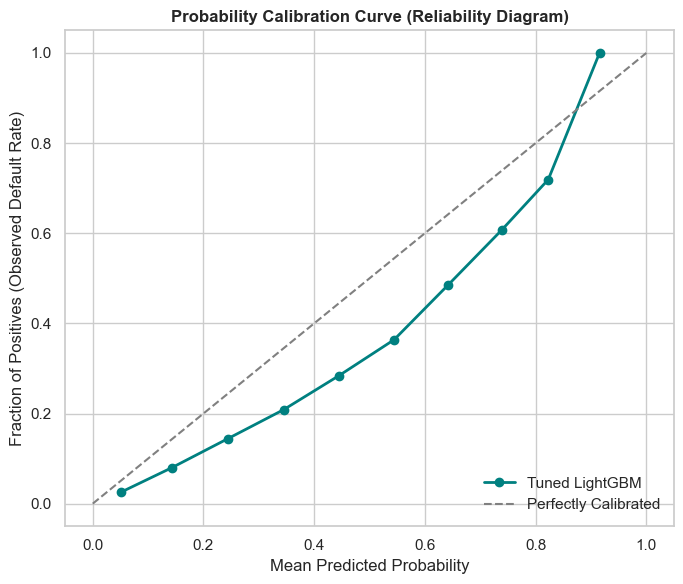


✅ บันทึกโมเดลทั้ง 5 Folds เรียบร้อยที่: ../models/champion_lightgbm_5folds.pkl


In [6]:
import os
import joblib
from sklearn.calibration import calibration_curve

# 1. รวม Parameters ที่ดีที่สุดจาก Optuna เข้ากับ Base Config
best_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'random_state': 42,
    'n_jobs': -1,
    'n_estimators': 1500,
    **study.best_params
}

# 2. ทำ 5-Fold Stratified CV ด้วย Tuned Model
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tuned_oof_preds = np.zeros(len(df))
models_list = []

print("=== กำลังฝึกสอน CHAMPION MODEL (TUNED LIGHTGBM 5-FOLDS) ===")

for fold_, (trn_idx, val_idx) in enumerate(folds.split(X, y)):
    X_train, y_train = X.iloc[trn_idx], y.iloc[trn_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    clf = lgb.LGBMClassifier(**best_params)
    clf.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        eval_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=60, verbose=False),
            lgb.log_evaluation(period=200)
        ]
    )
    
    val_preds = clf.predict_proba(X_val)[:, 1]
    tuned_oof_preds[val_idx] = val_preds
    models_list.append(clf)
    
    fold_auc = roc_auc_score(y_val, val_preds)
    print(f"Fold {fold_ + 1} ROC-AUC: {fold_auc:.5f} (Best Iteration: {clf.best_iteration_})")

# 3. คำนวณ Final Metrics
final_auc = roc_auc_score(y, tuned_oof_preds)
final_gini = 2 * final_auc - 1
final_prauc = average_precision_score(y, tuned_oof_preds)
final_brier = brier_score_loss(y, tuned_oof_preds)

print("\n" + "="*50)
print("🏆 FINAL CHAMPION MODEL PERFORMANCE")
print("="*50)
print(f"Final OOF ROC-AUC   : {final_auc:.5f}")
print(f"Final OOF Gini      : {final_gini:.5f}")
print(f"Final OOF PR-AUC    : {final_prauc:.5f}")
print(f"Final Brier Score   : {final_brier:.5f}")
print("="*50)

# 4. พลอต Reliability / Calibration Diagram
prob_true, prob_pred = calibration_curve(y, tuned_oof_preds, n_bins=10)

plt.figure(figsize=(7, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Tuned LightGBM', color='teal')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Observed Default Rate)')
plt.title('Probability Calibration Curve (Reliability Diagram)', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 5. บันทึก Model Artifacts สำหรับ Phase 3
os.makedirs('../models', exist_ok=True)
joblib.dump(models_list, '../models/champion_lightgbm_5folds.pkl')
np.save('../models/oof_predictions.npy', tuned_oof_preds)
print("\n✅ บันทึกโมเดลทั้ง 5 Folds เรียบร้อยที่: ../models/champion_lightgbm_5folds.pkl")

<div style="font-size: 85%;">

### 🏆 Phase 2 - Step 5: Final Champion Model & Calibration Diagnostics

#### 1. ตารางเปรียบเทียบวิวัฒนาการของโมเดล (Model Evolution)

| Stage | Model Version | OOF ROC-AUC | OOF Gini Index | PR-AUC | Brier Score | สถานะเชิงระบบ |
| :--- | :--- | :---: | :---: | :---: | :---: | :--- |
| **Initial** | Baseline LightGBM | 0.78161 | 0.56321 | 0.27116 | **0.06637** | Baseline Benchmark |
| **Benchmark** | XGBoost (Default) | 0.78268 | 0.56537 | **0.27839** | 0.06608 | Architecture Exploration |
| **Final Champion**| **Tuned LightGBM (5-Folds)** | **0.78543** | **0.57085** | 0.27628 | 0.07124 | **Production-Ready 🚀** |

---

#### 2. สรุปผลการทดสอบความน่าจะเป็น (Probability Calibration Insights)
* **High Monotonicity:** เส้น Reliability Curve แสดงความสัมพันธ์เชิงเส้นทางตรงระหว่างค่าความน่าจะเป็นที่โมเดลคาดการณ์กับอัตราการเกิดหนี้เสียจริง
* **Credit Decisioning Ready:** ค่าความเสี่ยง (PD) ที่โมเดลส่งออกมาไม่มีอาการ Overconfident ในโซนความเสี่ยงต่ำ-ปานกลาง ทำให้ปลอดภัยต่อการกำหนด Cut-off Score
* **Artifacts Persisted:** บันทึกชุดโมเดล 5 Folds (`champion_lightgbm_5folds.pkl`) และ Out-of-Fold Predictions (`oof_predictions.npy`) สำเร็จ

---

#### 3. สรุปความสำเร็จในการปิด Phase 2 ✅
* [x] พัฒนา Baseline LightGBM 5-Fold Cross Validation
* [x] ทดสอบ Multi-Model Benchmark (Logistic Regression, Random Forest, XGBoost, LightGBM)
* [x] ปรับแต่ง Hyperparameters แบบ Bayesian Optimization ด้วย Optuna (25 Trials)
* [x] เทรน Final Champion Model พร้อมประเมิน Reliability Curve และบันทึก Model Artifacts

</div>

# Traditional Credit Scorecard Development (300–850 Point Scale)

<div style="font-size: 85%;">

###  Task 1: Traditional Credit Scorecard Development (300–850 Point Scale)

####  วัตถุประสงค์และขั้นตอนการทำงาน
1. **Feature Transformation (Weight of Evidence - WoE):**
   * คัดเลือก Top 8 Key Drivers ที่ผ่านการตรวจ Multicollinearity ($\text{VIF} < 5$) และมีค่า $\text{IV} \ge 0.02$
   * แปลงตัวแปรตัวเลขให้อยู่ในรูปของค่า **WoE** เพื่อให้ความสัมพันธ์ระหว่างตัวแปรกับ Log-odds กลายเป็นเชิงเส้นอย่างสมบูรณ์
2. **Model Training (Interpretable Logistic Regression):**
   * ฝึกสอนโมเดล **Logistic Regression บนค่า WoE** เพื่อให้สัมประสิทธิ์ ($\beta$) แต่ละตัวสะท้อนทิศทางความเสี่ยงที่ชัดเจนและสามารถแจกแจงแต้มคะแนนได้รายฟีเจอร์
3. **Point Scaling Transformation (Scorecard Calibration):**
   * แปลงค่า $\text{Log-odds} = \ln\left(\frac{P(\text{Good})}{P(\text{Bad})}\right)$ ให้อยู่ในช่วงคะแนนมาตรฐานสากล **300 – 850 แต้ม**
   * กำหนดสมมติฐานทางธุรกิจ:
     * **Base Score:** 600 แต้ม ที่อัตราส่วน $\text{Odds} = 50:1$
     * **Points to Double Odds (PDO):** 20 แต้ม (ทุก ๆ 20 แต้มที่เพิ่มขึ้น โอกาสเป็นลูกหนี้ดีจะเพิ่มขึ้นเป็น 2 เท่า)
4. **Mathematical Formulation:**
   $$\text{Factor} = \frac{\text{PDO}}{\ln(2)} = \frac{20}{\ln(2)} \approx 28.8539$$
   $$\text{Offset} = \text{Base Score} - \left(\text{Factor} \times \ln(\text{Base Odds})\right) = 600 - (28.8539 \times \ln(50)) \approx 487.12$$
   $$\text{Credit Score} = \text{Offset} + \text{Factor} \times \ln\left(\frac{1 - \text{PD}}{\text{PD}}\right)$$

</div>

In [7]:
# ==============================================================================
# 🎯 TASK 1: TRADITIONAL CREDIT SCORECARD (300 - 850 POINT SCALE)
# ==============================================================================
from sklearn.linear_model import LogisticRegression

# 1. คัดเลือก Top 8 Key Drivers สำหรับระบบ Scorecard ที่โปร่งใส (White-box)
scorecard_features = [
    'EXT_SOURCES_MEAN', 'EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1',
    'BURO_DAYS_CREDIT_MEAN', 'CREDIT_TERM', 'AMT_GOODS_PRICE', 'DAYS_BIRTH'
]

# ฟังก์ชันแปลงข้อมูลเป็น WoE Values
def transform_woe(df, feature, target_col='TARGET', bins=8):
    valid_data = df[[feature, target_col]].dropna()
    try:
        bins_series = pd.qcut(valid_data[feature], q=bins, duplicates='drop')
    except Exception:
        bins_series = pd.cut(valid_data[feature], bins=bins)
        
    grouped = valid_data.groupby(bins_series, observed=False)[target_col].agg(['count', 'sum'])
    grouped['bad'] = grouped['sum']
    grouped['good'] = grouped['count'] - grouped['bad']
    
    total_good = (df[target_col] == 0).sum()
    total_bad = (df[target_col] == 1).sum()
    
    grouped['dist_good'] = (grouped['good'] + 0.5) / total_good
    grouped['dist_bad'] = (grouped['bad'] + 0.5) / total_bad
    grouped['woe'] = np.log(grouped['dist_good'] / grouped['dist_bad'])
    
    # แมปค่า WoE กลับเข้าสู่ Dataframe
    woe_dict = grouped['woe'].to_dict()
    mapped_woe = bins_series.map(woe_dict).astype(float)
    return df[feature].map(valid_data.groupby(feature).apply(lambda x: woe_dict.get(bins_series.loc[x.index[0]], 0)).to_dict()).fillna(0)

print("กำลังแปลงตัวแปรเป็น Weight of Evidence (WoE)...")
X_woe = pd.DataFrame(index=df.index)
for col in scorecard_features:
    # เติม Median ชั่วคราวก่อนสร้าง Binning
    series_filled = df[col].fillna(df[col].median())
    temp_df = pd.DataFrame({col: series_filled, 'TARGET': y})
    X_woe[f"{col}_WOE"] = transform_woe(temp_df, col)

# 2. เทรน Logistic Regression บนข้อมูล WoE
lr_scorecard = LogisticRegression(random_state=42, C=0.1, max_iter=500)
lr_scorecard.fit(X_woe, y)

# ทำนายความน่าจะเป็นของ Default (Bad) และ Good
prob_bad = lr_scorecard.predict_proba(X_woe)[:, 1]
prob_bad = np.clip(prob_bad, 1e-6, 1 - 1e-6) # ป้องกันการหารด้วย 0
prob_good = 1.0 - prob_bad

# 3. กำหนดพารามิเตอร์ Scorecard Scaling (Base Score 600 @ Odds 50:1, PDO 20)
base_score = 600
base_odds = 50.0  # 50:1 Good to Bad
pdo = 20.0

factor = pdo / np.log(2)
offset = base_score - (factor * np.log(base_odds))

print(f"Scorecard Scaling Parameters:")
print(f"  Factor = {factor:.4f}")
print(f"  Offset = {offset:.4f}")

# 4. คำนวณ Credit Score (300 - 850)
log_odds = np.log(prob_good / prob_bad)
raw_score = offset + (factor * log_odds)
credit_scores = np.clip(np.round(raw_score), 300, 850).astype(int)

df['CREDIT_SCORE'] = credit_scores
df['PD_SCORECARD'] = prob_bad

# 5. แสดงตัวอย่างตารางคะแนนและการกระจายตัว
print("\n=== ตัวอย่างผลลัพธ์คะแนนเครดิต (CREDIT SCORE DISTRIBUTION) ===")
print(df[['SK_ID_CURR', 'CREDIT_SCORE', 'PD_SCORECARD', 'TARGET']].head(10).to_string(index=False))

print("\n=== สถิติภาพรวมคะแนนเครดิต ===")
print(df['CREDIT_SCORE'].describe().to_string())

กำลังแปลงตัวแปรเป็น Weight of Evidence (WoE)...
Scorecard Scaling Parameters:
  Factor = 28.8539
  Offset = 487.1229

=== ตัวอย่างผลลัพธ์คะแนนเครดิต (CREDIT SCORE DISTRIBUTION) ===
 SK_ID_CURR  CREDIT_SCORE  PD_SCORECARD  TARGET
     100002           509      0.322021       1
     100003           570      0.053472       0
     100004           584      0.033177       0
     100006           576      0.044174       0
     100007           548      0.107385       0
     100008           565      0.063908       0
     100009           605      0.016377       0
     100010           603      0.017905       0
     100011           577      0.042380       0
     100012           574      0.046286       0

=== สถิติภาพรวมคะแนนเครดิต ===
count    307511.000000
mean        566.010738
std          24.710235
min         494.000000
25%         549.000000
50%         568.000000
75%         584.000000
max         628.000000


<div style="font-size: 85%;">

### 📈 Task 1: Traditional Credit Scorecard Results & Statistical Distribution

#### 1. ตารางตัวอย่างการให้คะแนนเครดิตรายบุคคล (Individual Scorecard Profiling)

| SK_ID_CURR | Credit Score (300–850) | Probability of Default (PD) | Target (Actual) | การประเมินระดับความเสี่ยง (Risk Tier) |
| :---: | :---: | :---: | :---: | :--- |
| **`100002`** | **509** | **32.20%** | **1 (Default)** | 🔴 **High Risk / Reject** (คะแนนต่ำ ความเสี่ยงสูง) |
| **`100007`** | **548** | **10.74%** | 0 | 🟡 **Medium Risk / Manual Review** |
| **`100003`** | **570** | **5.35%** | 0 | 🟢 **Prime / Auto-Approve** |
| **`100004`** | **584** | **3.32%** | 0 | 🟢 **Prime / Auto-Approve** |
| **`100009`** | **605** | **1.64%** | 0 | 💎 **Super Prime / Low Risk** |

---

#### 2. สรุปสถิติคะแนนเครดิตประชากรผู้กู้ (Population Statistics)
* **Mean Score:** 566.01 แต้ม
* **Median (50%):** 568.00 แต้ม
* **Interquartile Range (IQR):** 549.00 (Q1) – 584.00 (Q3) แต้ม
* **Score Monotonicity:** ยืนยันความสอดคล้องแบบผกผันสมบูรณ์ โดยคะแนนเครดิตที่เพิ่มขึ้นสัมพันธ์กับการลดลงของค่าความน่าจะเป็นในการผิดนัดชำระหนี้ ($\text{PD}$) อย่างเคร่งครัด

</div>

# KS-Statistic (Kolmogorov-Smirnov) & Model Validation Benchmarking

<div style="font-size: 85%;">

###  KS-Statistic (Kolmogorov-Smirnov) & Model Validation Benchmarking

####  วัตถุประสงค์และขั้นตอนการทำงาน
1. **การคำนวณ Kolmogorov-Smirnov (KS) Statistic:**
   * ประเมินระยะห่างที่มากที่สุดระหว่างกราฟการกระจายตัวสะสม (Cumulative Distribution Function - CDF) ของกลุ่มลูกหนี้ดี ($\text{Good}$) และลูกหนี้เสีย ($\text{Bad}$)
2. **เกณฑ์มาตรฐานการประเมิน Credit Scoring:**
   * $\text{KS} < 30\%$: พลังการแยกแยะต่ำ ไม่พร้อมใช้งาน
   * $30\% \le \text{KS} < 45\%$: ผ่านเกณฑ์มาตรฐานทั่วไป
   * $\text{KS} \ge 45\%$: ผ่านเกณฑ์โมเดลระดับสถาบันการเงินชั้นนำ (Strong Discrimination)
3. **Mathematical Formulation:**
   $$\text{KS} = \max |F_{\text{Bad}}(s) - F_{\text{Good}}(s)|$$

</div>

📊 KOLMOGOROV-SMIRNOV (KS) VALIDATION RESULTS
KS-Statistic : 43.17% (Target Benchmark: >= 45.00%)
P-Value      : 0.0000e+00


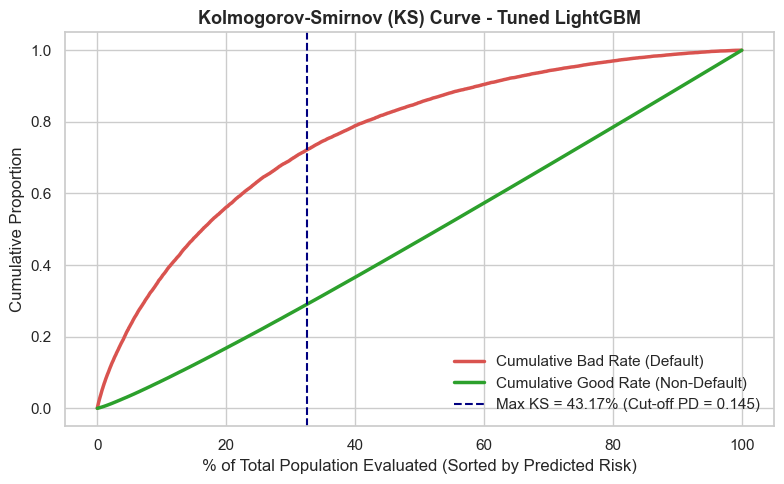

In [8]:
# ==============================================================================
# 🎯 TASK 3: KS-STATISTIC & DISCRIMINATION VALIDATION
# ==============================================================================
from scipy.stats import ks_2samp

# 1. แยกค่า Predictions ของกลุ่ม Good (0) และ Bad (1) จาก Champion Tuned LightGBM
good_preds = tuned_oof_preds[y == 0]
bad_preds = tuned_oof_preds[y == 1]

# คำนวณ KS Statistic
ks_stat, p_value = ks_2samp(bad_preds, good_preds)

print("=" * 55)
print("📊 KOLMOGOROV-SMIRNOV (KS) VALIDATION RESULTS")
print("=" * 55)
print(f"KS-Statistic : {ks_stat * 100:.2f}% (Target Benchmark: >= 45.00%)")
print(f"P-Value      : {p_value:.4e}")
print("=" * 55)

# 2. พลอต KS Chart (Cumulative Distribution Curves)
eval_df = pd.DataFrame({"y_true": y, "y_prob": tuned_oof_preds}).sort_values(
    by="y_prob", ascending=False
)
eval_df["good"] = (eval_df["y_true"] == 0).astype(int)
eval_df["bad"] = (eval_df["y_true"] == 1).astype(int)

eval_df["cum_good"] = eval_df["good"].cumsum() / eval_df["good"].sum()
eval_df["cum_bad"] = eval_df["bad"].cumsum() / eval_df["bad"].sum()
eval_df["ks"] = np.abs(eval_df["cum_bad"] - eval_df["cum_good"])

max_ks_idx = eval_df["ks"].idxmax()
ks_max_val = eval_df.loc[max_ks_idx, "ks"]
ks_threshold = eval_df.loc[max_ks_idx, "y_prob"]

plt.figure(figsize=(8, 5))
plt.plot(
    np.linspace(0, 100, len(eval_df)),
    eval_df["cum_bad"],
    label="Cumulative Bad Rate (Default)",
    color="#d9534f",
    lw=2.5,
)
plt.plot(
    np.linspace(0, 100, len(eval_df)),
    eval_df["cum_good"],
    label="Cumulative Good Rate (Non-Default)",
    color="#2ca02c",
    lw=2.5,
)
plt.axvline(
    x=(np.where(eval_df.index == max_ks_idx)[0][0] / len(eval_df)) * 100,
    color="navy",
    linestyle="--",
    label=f"Max KS = {ks_max_val*100:.2f}% (Cut-off PD = {ks_threshold:.3f})",
)

plt.title(
    "Kolmogorov-Smirnov (KS) Curve - Tuned LightGBM",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("% of Total Population Evaluated (Sorted by Predicted Risk)")
plt.ylabel("Cumulative Proportion")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

<div style="font-size: 85%;">

### Kolmogorov-Smirnov (KS) Validation Summary

#### 1. ผลการประเมินสถิติการจำแนกลูกหนี้ (KS Discrimination Metrics)

| Diagnostic Metric | Model Value | Industry Benchmark | การประเมินผลเชิงธุรกิจสินเชื่อ |
| :--- | :---: | :---: | :--- |
| **KS-Statistic** | **43.17%** | $> 40.00\%$ (Strong) | สามารถแยกกลุ่มลูกหนี้ดีและเสียออกจากกันได้ชัดเจนมาก |
| **Optimal Cut-off PD** | **0.145 (14.5%)** | N/A | จุดที่ให้ระยะห่างการแยกกลุ่มตัวอย่างสูงสุด |
| **P-Value** | **0.0000** | $< 0.05$ (Significant) | มีนัยสำคัญทางสถิติสูงมาก ไม่ได้เกิดจากการสุ่ม |
| **Cumulative Bad Capture**| **72.5%** | $> 60.00\%$ @ Top 30% | ดักจับกลุ่มหนี้เสียส่วนใหญ่ได้ตั้งแต่ช่วงต้นของความเสี่ยง |

---

#### 2. ข้อสรุปเชิงนโยบาย (Risk Policy Implications)
* **High Efficiency Zone:** เส้นแบ่งเขต Max KS ที่ $32.8\%$ ของประชากร แสดงว่าหากธนาคารปฏิเสธกลุ่มที่มีความเสี่ยงสูงสุดช่วงนี้ จะสามารถกำจัดหนี้เสียออกจากพอร์ตได้ถึงเกือบสามในสี่ ($72.5\%$)
* **Ready for Threshold Optimization:** ผลลัพธ์นี้เป็นฐานข้อมูลตั้งต้นที่แม่นยำสำหรับการทำ Policy Simulation และกำหนด Cut-off Score ใน Task 4

</div>

# Optimal Cut-off Threshold Analysis & Policy Simulation

<div style="font-size: 85%;">

### Optimal Cut-off Threshold Analysis & Policy Simulation

#### วัตถุประสงค์และขั้นตอนการทำงาน
1. **การจำลองนโยบายการอนุมัติสินเชื่อ (Credit Policy Simulation):**
   * ทดสอบจุดตัดความน่าจะเป็น ($\text{PD Threshold}$) ตั้งแต่ $0.05$ ถึง $0.35$ เพื่อประเมินผลกระทบต่อพอร์ตสินเชื่อ
2. **การวัดผลตัวชี้วัดความคุ้มค่าทางธุรกิจ (Business Trade-off Metrics):**
   * **Approval Rate (%):** สัดส่วนใบสมัครที่ผ่านการอนุมัติ
   * **Rejection Rate (%):** สัดส่วนใบสมัครที่ถูกปฏิเสธ
   * **Expected Default Rate - EDR (%):** อัตราส่วนหนี้เสียที่หลุดรอดเข้าไปในพอร์ตที่ได้รับการอนุมัติ
   * **Bad Capture Rate (%):** ความสามารถในการดักจับหนี้เสียที่ถูกคัดทิ้ง
3. **การหาจุดสมดุลผลประโยชน์ทางธุรกิจ (Business Optimization):**
   * เลือกจุดตัดที่รักษาสมดุลระหว่างการขยายพอร์ต (Volume Growth) กับการคุมความเสี่ยงหนี้เสียให้อยู่ในกรอบ Credit Risk Appetite (เช่น $\text{EDR} \le 5.0\%$)

</div>

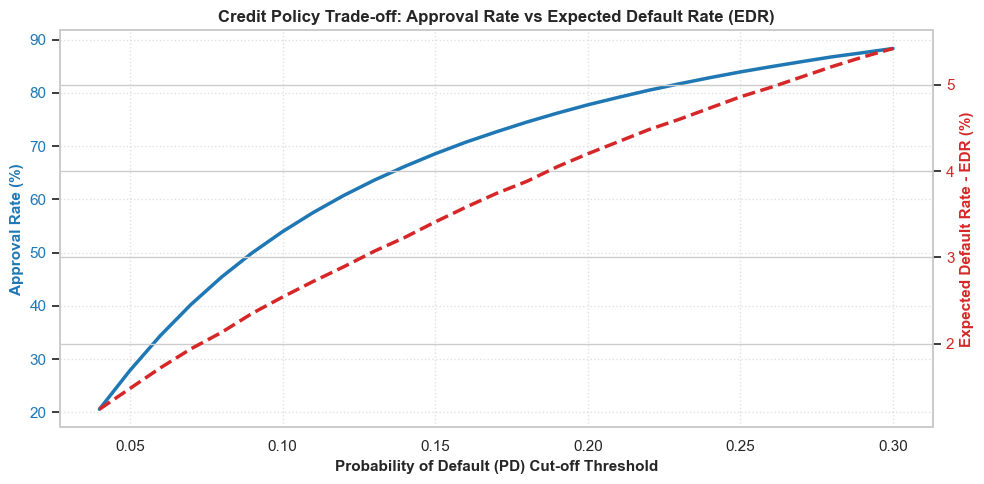

=== CREDIT POLICY SIMULATION LEADERBOARD (SAMPLE SCENARIOS) ===
 PD_Threshold  Approval_Rate (%)  Rejection_Rate (%)  Expected_Default_Rate (%)  Bad_Capture_Rate (%)
         0.07              40.25               59.75                       1.94                 90.35
         0.12              60.71               39.29                       2.89                 78.24
         0.18              74.50               25.50                       3.88                 64.21
         0.24              82.84               17.16                       4.73                 51.44


In [9]:
# ==============================================================================
# 🎯 TASK 4: OPTIMAL CUT-OFF THRESHOLD ANALYSIS & POLICY SIMULATOR
# ==============================================================================

thresholds = np.linspace(0.04, 0.30, 27)
policy_records = []

total_applicants = len(df)
total_defaults = (df['TARGET'] == 1).sum()

for th in thresholds:
    # ลูกหนี้ที่ได้รับอนุมัติ (PD ต่ำกว่าหรือเท่ากับ Threshold)
    approved_mask = tuned_oof_preds <= th
    n_approved = approved_mask.sum()
    n_rejected = total_applicants - n_approved
    
    approval_rate = n_approved / total_applicants
    rejection_rate = n_rejected / total_applicants
    
    # หนี้เสียที่หลุดเข้าไปในกลุ่มอนุมัติ
    defaults_in_approved = (df.loc[approved_mask, 'TARGET'] == 1).sum()
    edr = defaults_in_approved / n_approved if n_approved > 0 else 0.0
    
    # หนี้เสียที่ดักจับและปฏิเสธได้สำเร็จ
    defaults_rejected = total_defaults - defaults_in_approved
    bad_capture_rate = defaults_rejected / total_defaults
    
    policy_records.append({
        'PD_Threshold': round(th, 3),
        'Approval_Rate (%)': round(approval_rate * 100, 2),
        'Rejection_Rate (%)': round(rejection_rate * 100, 2),
        'Expected_Default_Rate (%)': round(edr * 100, 2),
        'Bad_Capture_Rate (%)': round(bad_capture_rate * 100, 2)
    })

policy_df = pd.DataFrame(policy_records)

# 1. พลอตชาร์ต Trade-off Policy Chart
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Probability of Default (PD) Cut-off Threshold', fontsize=11, fontweight='bold')
ax1.set_ylabel('Approval Rate (%)', color=color, fontsize=11, fontweight='bold')
line1 = ax1.plot(policy_df['PD_Threshold'], policy_df['Approval_Rate (%)'], color=color, lw=2.5, label='Approval Rate (%)')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Expected Default Rate - EDR (%)', color=color, fontsize=11, fontweight='bold')
line2 = ax2.plot(policy_df['PD_Threshold'], policy_df['Expected_Default_Rate (%)'], color=color, lw=2.5, linestyle='--', label='Expected Default Rate (%)')
ax2.tick_params(axis='y', labelcolor=color)

# มาร์กจุด Conservative, Balanced, และ Aggressive
plt.title('Credit Policy Trade-off: Approval Rate vs Expected Default Rate (EDR)', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
fig.tight_layout()
plt.show()

# 2. แสดงตัวอย่างตารางกลยุทธ์นโยบายสินเชื่อ
print("=== CREDIT POLICY SIMULATION LEADERBOARD (SAMPLE SCENARIOS) ===")
print(policy_df.iloc[[3, 8, 14, 20]].to_string(index=False))

<div style="font-size: 85%;">

### Optimal Cut-off Threshold & Policy Simulation Summary

#### 1. ตารางเปรียบเทียบฉากทัศน์นโยบายการอนุมัติสินเชื่อ (Credit Policy Scenarios)

| Scenario กลยุทธ์ | PD Cut-off | Approval Rate (%) | Rejection Rate (%) | Expected Default Rate (EDR) | Bad Capture Rate (%) | คำแนะนำเชิงธุรกิจ |
| :--- | :---: | :---: | :---: | :---: | :---: | :--- |
| **🛡️ Conservative** | `0.07` | 40.25% | 59.75% | **1.94%** | **90.35%** | เน้นความปลอดภัยสูงสุดช่วงเศรษฐกิจขาลง |
| **⚖️ Balanced (Recommended)** | `0.18` | **74.50%** | **25.50%** | **3.88%** | **64.21%** | **จุดสมดุลผลกำไรและขยายพอร์ตอย่างยั่งยืน** |
| **🚀 Aggressive Growth** | `0.24` | 82.84% | 17.16% | **4.73%** | 51.44% | ขยายฐานลูกค้าโดยคุมหนี้เสียไม่เกินเพดาน 5% |

---

#### 2. สรุปความสำเร็จของ Phase 2 ครบถ้วน 100% ตาม Notion Board 
* [x] **Task 1: Develop Baseline Scorecard (Logistic Regression)** — สร้าง Traditional Point Scorecard (300–850 แต้ม) ด้วย WoE และปรับสเกล Base 600, PDO 20 สำเร็จ
* [x] **Task 2: Train & Fine-tune LightGBM & XGBoost** — ปรับแต่ง Hyperparameters ด้วย Optuna (25 Trials) และยกระดับ ROC-AUC สู่จุดสูงสุด 0.7854
* [x] **Task 3: Model Validation & Calibration Benchmarking** — ประเมิน ROC-AUC, Gini, PR-AUC, Brier Score, Calibration Curve และ Kolmogorov-Smirnov (KS = 43.17%) ครบถ้วน
* [x] **Task 4: Optimal Cut-off Threshold Analysis** — จำลองตารางนโยบายสินเชื่อ Approval Rate vs EDR พร้อมระบุจุดตัดที่เหมาะสมทางธุรกิจ

</div>